# Лабораторная работа 4
# Правильный многоугольник Рело. Векторизация вычислений в `numpy`
Гордеенко Ангелина 10.04.2026

# Задание 4.1. Построение треугольника Рело
# Выполнение задания 4.1

Полагаем, что заданы координаты центра правильного треугольника Рело `center` , ширина треугольника Рело `r` и количество точек для описания одной стороны треугольника Рело `N.`

Определим переменные

In [58]:
import numpy as np
import matplotlib.pyplot as plt

n = 3
center = np.array([0,0])
r = 10.
N = 100


Вершины правильного многоугольника расположены на окружности, описанной вокруг многоугольника. Радиус `R` окружности, описанной вокруг правильного *n*-угольника с длиной стороны , вычисляется по формуле</br>
$$R=\frac{l}{2sin\pi/n} $$
Длина стороны *l* правильного треугольника, на котором будем строить треугольник Рело, совпадает с шириной треугольника Рело

In [59]:
l = r

R = l/(2*np.sin(np.pi/n))



Зафиксируем прямоугольную декартову систему координат. Центр треугольника размещаем в точке `center` . Построим матрицу `vertices` с координатами вершин правильного треугольника, используя параметрическое описание точек описанной окружности по формуле $x(t)=x_{\text{0}}+Rcos(t), y(t)=y_{\text{0}}+Rsin(t) $, для значений $t \in {0,2\pi/3,4\pi/3} $.

In [60]:
t = np.arange(0,2*np.pi, 2*np.pi/n)

vertices = center + R*np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

Для доступа к элементам матрицы в numpy можно использовать индексацию с двумя индексами

In [61]:
vertices[0,0], vertices[0,:], vertices[:,1]


(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

Построим изображение вершин треугольника

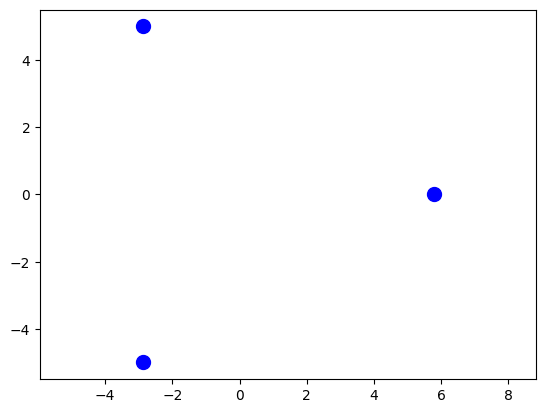

In [62]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.axis('equal');

## Этап 2. Представление одной стороны треугольника Рело

Обозначим через $a$ центральный угол, соответствующий стороне правильного n-угольника. Тогда
$$ a=2\pi/n$$

Обозначим через $b$ центральный угол, соответствующий стороне правильного многоугольника Рело, когда центр окружности расположен в вершине правильного многоугольника. Тогда

In [63]:
alpha = 2*np.pi/n
beta = alpha/2

Вычислим массив angle значений угла для построения координат точек стороны треугольника Рело, состоящий из N элементов

In [64]:
angle = np.linspace(-beta/2, beta/2, N)

In [65]:
side0 = vertices[0] + r*np.transpose([np.cos(np.pi + angle),
 np.sin(np.pi + angle)])

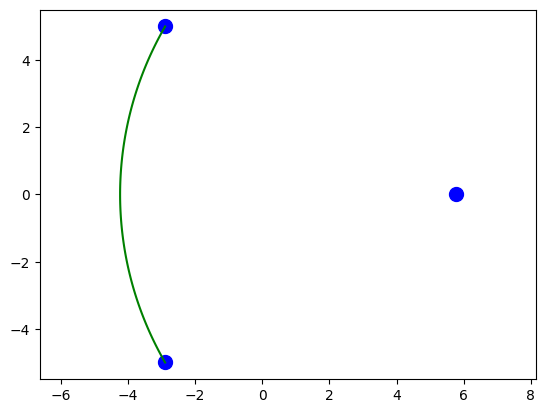

In [66]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'g-',markersize=20)
plt.axis('equal');


Вычислим матрицу `side1` с координатами точек, описывающих сторону треугольника Рело относительно второй вершины `vertices[1]`. Сторона представляет собой дугу окружности радиуса $r$ с центром в точке `vertices[1]` и значением угла $[\pi - \beta / 2 + \alpha, \pi + \beta / 2 + \alpha]$

In [67]:
side1 = vertices[1] + r*np.transpose([np.cos(np.pi + angle + alpha), np.sin(np.pi + angle + alpha)])


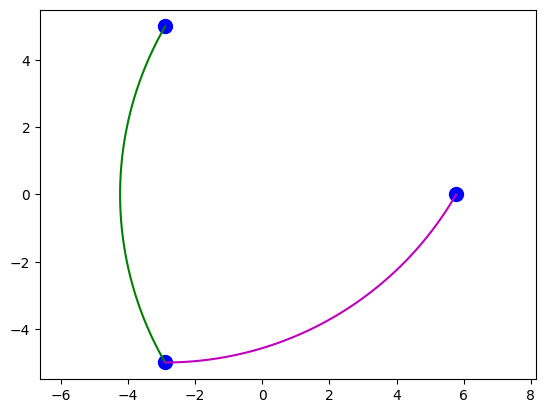

In [68]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'g-',markersize=20)
plt.plot(side1[:,0],side1[:,1],'m-',markersize=20)
plt.axis('equal');

## Этап 3. Моделирование границы треугольника Рело
Создадим СПИСОК из матриц, каждая их которых содержит координаты точек одной из сторон треугольника Рело

In [69]:
list_sides = [vertices[i] +r*np.transpose([np.cos(angle + np.pi + i*alpha), np.sin(angle + np.pi + i*alpha)]) for i in range(n)]

С помощью фунции `concatenate` из расширения `numpy` объединим массивы,
созданные для каждой из сторон треугольника Рело, в единый массив `sides`

In [70]:
sides = np.concatenate(list_sides)


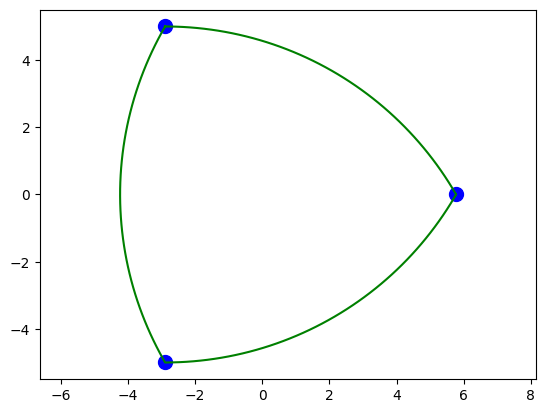

In [71]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(sides[:,0],sides[:,1],'g-',markersize=20)
plt.axis('equal');


# Задание 4.2. Построение правильного многоугольника Рело

n2 - кол-во сторон</br>
N2 - кол-во точек разбиения</br> 
r2 - ширина</br>
center2 - центр</br>

Однако нужно найти радиус описанной окружности около многоульника, он задается формулой $$R=\frac{l}{2sin\pi/n} $$
но мы не знаем длину строны многоульника
Радиус круга $r$ согласован с длиной стороны $l$ правильного многоугольника таким образом, чтобы окружность радиуса $r$ с центром в вершине правильного $n$-угольника проходила через две соседние вершины правильного $n$-угольника, противолежащие центру.
При этом за угол $b$ мы как раз таки обозначили угол, соответствующий стороне правильного многоугольника, когда центр лежит в вершине правильного $n$-угольника. С другой стороны, это центральный угол окружности радиусом $r$, центр которого расположен в вершине, а хорда лежащая напротив этого угла как раз таки является стороной многоульника. Её можно найти по теореме косинусов для этого треугольника 
$$l^2=r^2+r^2-2*r*r*\cos(b) $$
$$
l = \sqrt{2*r^2(1-\cos(b))}
$$

In [72]:
# Этап 1. Вычисление координат вершин
n2 = 5
center2 = np.array([0, 0])
r2 = 10.0
N2 = 100

alpha2 = 2 * np.pi / n2
l2 = 2 * r2 * np.sin(np.pi / (2 * n2))
R2 = l2 / (2 * np.sin(np.pi / n2))

t2 = np.arange(0, 2 * np.pi, 2 * np.pi / n2)
vertices2 = center2 + R2 * np.transpose([np.cos(t2), np.sin(t2)])

In [73]:
# Этап 2. Представление одной стороны
beta2 = alpha2 / 2
angle2 = np.linspace(-beta2/2, beta2/2, N2)

side02 = vertices2[0] + r2 * np.transpose([np.cos(np.pi + angle2), np.sin(np.pi + angle2)])

In [74]:
# Этап 3. Моделирование границы
list_sides2 = [vertices2[i] + r2 * np.transpose([np.cos(angle2 + np.pi + i * alpha2), 
                                                   np.sin(angle2 + np.pi + i * alpha2)]) 
               for i in range(n2)]

sides2 = np.concatenate(list_sides2)

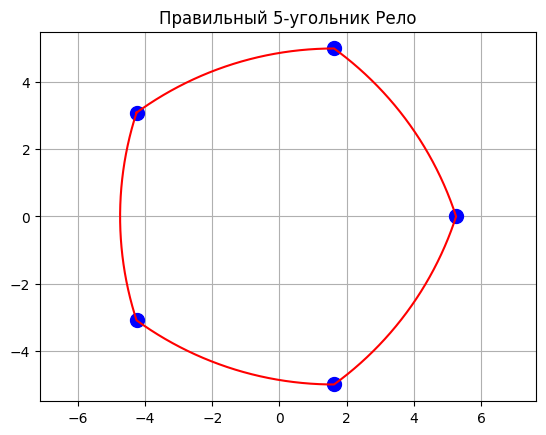

In [75]:
# Визуализация
plt.plot(vertices2[:, 0], vertices2[:, 1], 'b.', markersize=20)
plt.plot(sides2[:, 0], sides2[:, 1], 'r-', linewidth=1.5)
plt.axis('equal')
plt.title(f'Правильный {n2}-угольник Рело')
plt.grid(True)
plt.show()

# Задание 4.3. Результирующая пользовательская функция

In [76]:


def regular_polygon_Relo(n: int = 3, center: np.ndarray = np.array([0, 0]), 
                          r: float = 1.0, N: int = 100) -> np.ndarray:
    """
    Возвращает матрицу координат точек границы правильного многоугольника Рело.
    
    Параметры
    ---------
    n : int, нечётное, >2
        Количество вершин правильного многоугольника Рело
    center : np.ndarray, shape=(2,)
        Координаты центра [x, y]
    r : float, >0
        Ширина правильного многоугольника Рело
    N : int, >0
        Количество точек для описания одной стороны
    
    Возвращает
    ----------
    np.ndarray, shape=(n*N, 2)
        Массив координат точек границы
    """
    # Проверка аргументов
    assert isinstance(n, int), "n должно быть целым числом"
    assert n > 2, "n должно быть больше 2"
    assert n % 2 == 1, "n должно быть нечётным"
    assert isinstance(center, np.ndarray) and center.shape == (2,), "center должен быть массивом shape=(2,)"
    assert isinstance(r, (int, float)) and r > 0, "r должно быть положительным числом"
    assert isinstance(N, int) and N > 0, "N должно быть натуральным числом"
    
    # Вычисление длины стороны
    side_length = 2 * r * np.sin(np.pi / (2 * n))
    
    # Радиус описанной окружности
    R_circum = side_length / (2 * np.sin(np.pi / n))
    
    # Углы вершин
    alpha = 2 * np.pi / n
    vertex_angles = np.arange(0, 2 * np.pi, alpha)
    
    # Координаты вершин
    vertices = center + R_circum * np.transpose([np.cos(vertex_angles), np.sin(vertex_angles)])
    
    # Углы для дуги
    beta = alpha / 2
    arc_angles = np.linspace(-beta/2, beta/2, N)
    
    # Построение всех сторон
    arcs_list = [vertices[i] + r * np.transpose([np.cos(arc_angles + np.pi + i * alpha),
                                                   np.sin(arc_angles + np.pi + i * alpha)])
                 for i in range(n)]
    
    # Объединение в один массив
    return np.concatenate(arcs_list)

In [77]:
# Проверка аннотаций и документации
print(regular_polygon_Relo.__annotations__)
print(regular_polygon_Relo.__doc__)

{'n': <class 'int'>, 'center': <class 'numpy.ndarray'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}

Возвращает матрицу координат точек границы правильного многоугольника Рело.

Параметры
---------
n : int, нечётное, >2
    Количество вершин правильного многоугольника Рело
center : np.ndarray, shape=(2,)
    Координаты центра [x, y]
r : float, >0
    Ширина правильного многоугольника Рело
N : int, >0
    Количество точек для описания одной стороны

Возвращает
----------
np.ndarray, shape=(n*N, 2)
    Массив координат точек границы



In [78]:
# Создание модуля relo.py

module_content = '''import numpy as np

def regular_polygon_Relo(n: int = 3, center: np.ndarray = np.array([0, 0]), 
                          r: float = 1.0, N: int = 100) -> np.ndarray:
    """
    Возвращает матрицу координат точек границы правильного многоугольника Рело.
    
    Параметры
    ---------
    n : int, нечётное, >2
        Количество вершин правильного многоугольника Рело
    center : np.ndarray, shape=(2,)
        Координаты центра [x, y]
    r : float, >0
        Ширина правильного многоугольника Рело
    N : int, >0
        Количество точек для описания одной стороны
    
    Возвращает
    ----------
    np.ndarray, shape=(n*N, 2)
        Массив координат точек границы
    """
    assert isinstance(n, int), "n должно быть целым числом"
    assert n > 2, "n должно быть больше 2"
    assert n % 2 == 1, "n должно быть нечётным"
    assert isinstance(center, np.ndarray) and center.shape == (2,), "center должен быть массивом shape=(2,)"
    assert isinstance(r, (int, float)) and r > 0, "r должно быть положительным числом"
    assert isinstance(N, int) and N > 0, "N должно быть натуральным числом"
    
    side_length = 2 * r * np.sin(np.pi / (2 * n))
    R_circum = side_length / (2 * np.sin(np.pi / n))
    alpha = 2 * np.pi / n
    vertex_angles = np.arange(0, 2 * np.pi, alpha)
    vertices = center + R_circum * np.transpose([np.cos(vertex_angles), np.sin(vertex_angles)])
    beta = alpha / 2
    arc_angles = np.linspace(-beta/2, beta/2, N)
    arcs_list = [vertices[i] + r * np.transpose([np.cos(arc_angles + np.pi + i * alpha),
                                                   np.sin(arc_angles + np.pi + i * alpha)])
                 for i in range(n)]
    return np.concatenate(arcs_list)
'''

with open('relo.py', 'w', encoding='utf-8') as f:
    f.write(module_content)
    

In [79]:
# Проверка импорта из созданного модуля
import relo

print("Аннотации из модуля:")
print(relo.regular_polygon_Relo.__annotations__)
print("\nДокументация из модуля:")
print(relo.regular_polygon_Relo.__doc__)

Аннотации из модуля:
{'n': <class 'int'>, 'center': <class 'numpy.ndarray'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}

Документация из модуля:

Возвращает матрицу координат точек границы правильного многоугольника Рело.

Параметры
---------
n : int, нечётное, >2
    Количество вершин правильного многоугольника Рело
center : np.ndarray, shape=(2,)
    Координаты центра [x, y]
r : float, >0
    Ширина правильного многоугольника Рело
N : int, >0
    Количество точек для описания одной стороны

Возвращает
----------
np.ndarray, shape=(n*N, 2)
    Массив координат точек границы



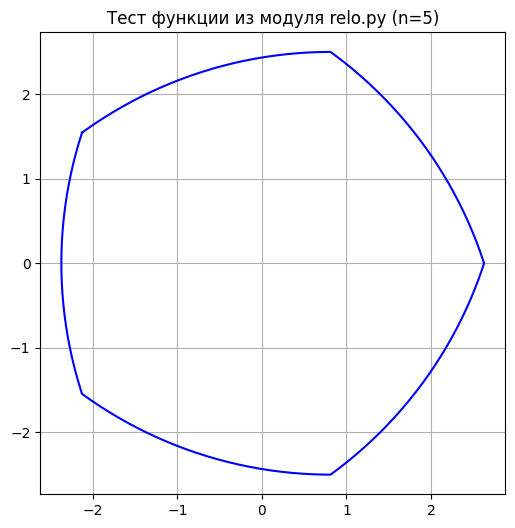

In [80]:
# Тест работы импортированной функции
boundary_test = relo.regular_polygon_Relo(5, np.array([0, 0]), 5.0, 50)

plt.figure(figsize=(6, 6))
plt.plot(boundary_test[:, 0], boundary_test[:, 1], 'b-', linewidth=1.5)
plt.axis('equal')
plt.title('Тест функции из модуля relo.py (n=5)')
plt.grid(True)
plt.show()

# Задание 4.4. Тестирование функции

In [81]:


# Очистка ядра 
import numpy as np
import matplotlib.pyplot as plt
from relo import regular_polygon_Relo

In [82]:
test_cases = [
    (4, np.array([0, 0]), 1.0, 100, "n=4 (чётное)"),
    (2, np.array([0, 0]), 1.0, 100, "n=2 (меньше 3)"),
    (3.5, np.array([0, 0]), 1.0, 100, "n=3.5 (не целое)"),
    (3, [0, 0], 1.0, 100, "center не массив"),
    (3, np.array([0, 0, 0]), 1.0, 100, "center.shape=(3,)"),
    (3, np.array([0, 0]), -5.0, 100, "r отрицательное"),
    (3, np.array([0, 0]), 0, 100, "r=0"),
    (3, np.array([0, 0]), 1.0, 0, "N=0"),
    (3, np.array([0, 0]), 1.0, -10, "N отрицательное"),
    (3, np.array([0, 0]), 1.0, 100.5, "N не целое"),
]

for args in test_cases:
    n, center, r, N, desc = args
    try:
        relo.regular_polygon_Relo(n, center, r, N)
        print(f" - {desc}: ОШИБКА НЕ ВОЗНИКЛА (должна была)")
    except AssertionError as e:
        print(f" + {desc}: AssertionError - {e}")
    except Exception as e:
        print(f"? {desc}: другая ошибка - {type(e).__name__}: {e}")

 + n=4 (чётное): AssertionError - n должно быть нечётным
 + n=2 (меньше 3): AssertionError - n должно быть больше 2
 + n=3.5 (не целое): AssertionError - n должно быть целым числом
 + center не массив: AssertionError - center должен быть массивом shape=(2,)
 + center.shape=(3,): AssertionError - center должен быть массивом shape=(2,)
 + r отрицательное: AssertionError - r должно быть положительным числом
 + r=0: AssertionError - r должно быть положительным числом
 + N=0: AssertionError - N должно быть натуральным числом
 + N отрицательное: AssertionError - N должно быть натуральным числом
 + N не целое: AssertionError - N должно быть натуральным числом


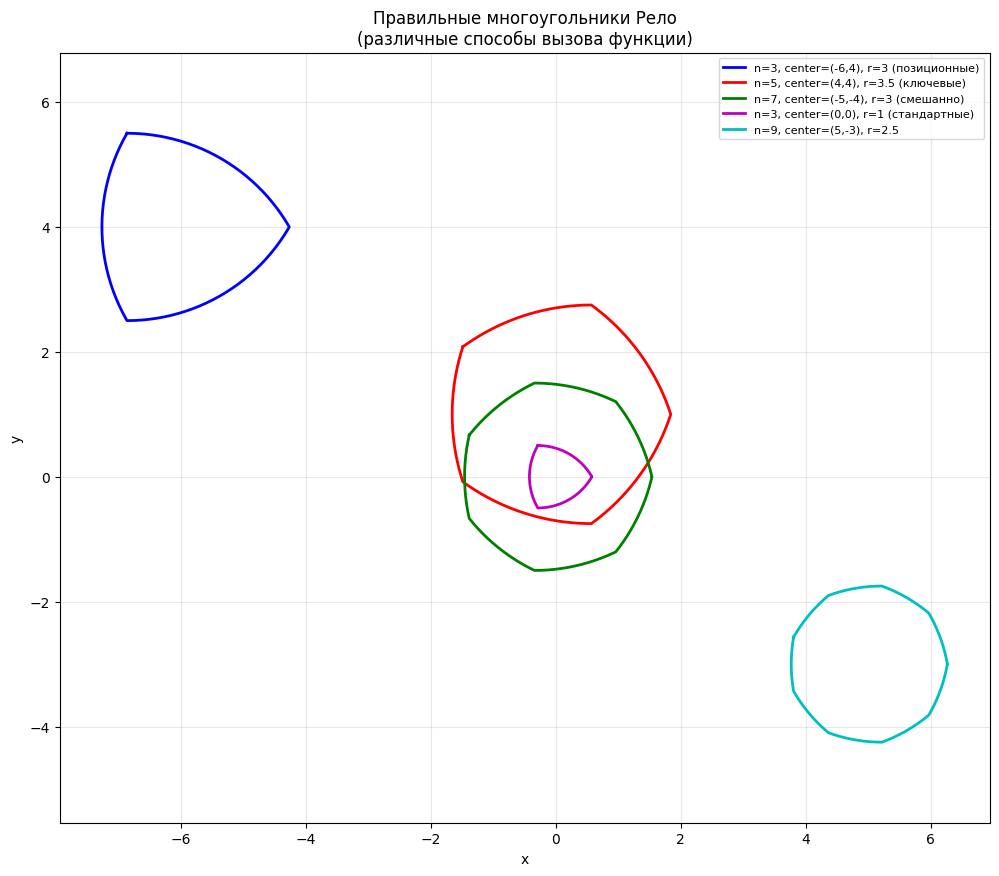

In [83]:
# Задание 4.4(б) - Построение в одной системе координат

plt.figure(figsize=(12, 10))

# 1. Все аргументы позиционные
boundary1 = relo.regular_polygon_Relo(3, np.array([-6, 4]), 3.0, 80)
plt.plot(boundary1[:, 0], boundary1[:, 1], 'b-', linewidth=2, label='n=3, center=(-6,4), r=3 (позиционные)')

# 2. Все аргументы ключевые
boundary2 = relo.regular_polygon_Relo(n=5, center=np.array([0, 1]), r=3.5, N=120)
plt.plot(boundary2[:, 0], boundary2[:, 1], 'r-', linewidth=2, label='n=5, center=(4,4), r=3.5 (ключевые)')

# 3. Аргументы позиционные и ключевые смешанно
boundary3 = relo.regular_polygon_Relo(7, np.array([0, 0]), r=3.0, N=100)
plt.plot(boundary3[:, 0], boundary3[:, 1], 'g-', linewidth=2, label='n=7, center=(-5,-4), r=3 (смешанно)')

# 4. Все аргументы стандартные
boundary4 = relo.regular_polygon_Relo()
plt.plot(boundary4[:, 0], boundary4[:, 1], 'm-', linewidth=2, label='n=3, center=(0,0), r=1 (стандартные)')

# Дополнительные фигуры для наглядности
boundary5 = relo.regular_polygon_Relo(9, np.array([5, -3]), r=2.5, N=100)
plt.plot(boundary5[:, 0], boundary5[:, 1], 'c-', linewidth=2, label='n=9, center=(5,-3), r=2.5')

plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Правильные многоугольники Рело\n(различные способы вызова функции)')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

# Контрольные вопросы
Вопрос 1. Дайте определение правильного многоугольника Рёло.


Правильный n-угольник Рело представляет собой область пересечения n кругов радиуса r с центрами в вершинах правильного n-угольника с нечётным числом сторон длины l. Радиус круга r согласован с длиной стороны l правильного многоугольника таким образом, чтобы окружность радиуса r с центром в вершине правильного n-угольника проходила через две соседние вершины правильного n-угольника, противолежащие центру.

Вопрос 2. Дайте определение ширины правильного многоугольника Рёло.


Ширина фигуры — это расстояние между опорными прямыми. Опорные прямые фигуры — это две параллельные прямые, которые касаются фигуры, но не пересекают её. Фигура постоянной ширины — это геометрическая фигура, для которой расстояние между любыми опорными прямыми всегда одинаково. Ширина правильного многоугольника Рело равна радиусу r пересекающихся кругов

Вопрос 3. Сформулируйте и решите математическую задачу вычисления радиуса R окружности, описанной вокруг правильного n-угольника, если задана ширина r правильного многоугольника Рёло.

Радиус R окружности, описанной вокруг правильного n-угольника с длиной стороны l, вычисляется по формуле: $$R=\frac{l}{2sin\pi/n} $$
Для правильного многоугольника Рело с нечётным n ширина r связана с длиной стороны l соотношением: $$ l = 2rsin(\frac{\pi}{2n})$$
Подставляя l в формулу для R, получаем:
$$ R = \frac{2rsin(\frac{\pi}{2n})}{2sin(\frac{\pi}{n})} = \frac{rsin(\frac{\pi}{2n})}{sin(\frac{\pi}{n})}$$
Вопрос 4. Напишите функцию, которая вычисляет координаты вершин правильного многоугольника Рёло.

In [84]:
import numpy as np

def get_vertices(n, center, r):
    """
    Вычисляет координаты вершин правильного n-угольника Рело.
    
    Параметры:
    n : int - количество вершин (нечётное)
    center : np.ndarray - координаты центра [x, y]
    r : float - ширина многоугольника Рело
    
    Возвращает:
    np.ndarray - матрица координат вершин
    """
    # Вычисление длины стороны
    side_length = 2 * r * np.sin(np.pi / (2 * n))
    
    # Радиус описанной окружности
    R = side_length / (2 * np.sin(np.pi / n))
    
    # Углы вершин
    alpha = 2 * np.pi / n
    angles = np.arange(0, 2 * np.pi, alpha)
    
    # Координаты вершин
    vertices = center + R * np.transpose([np.cos(angles), np.sin(angles)])
    
    return vertices

Вопрос 5. Напишите подробно и проиллюстрируйте, как получено аналитическое выражение для описания стороны правильного n-угольника Рёло
Обозначим:

- $\alpha$ = 2$\pi$/n — центральный угол, соответствующий стороне правильного n-угольника

- $\beta$ =  $\alpha$/2 — центральный угол, соответствующий стороне правильного многоугольника Рело
Сторона представляет собой дугу окружности радиуса r с центром в вершине правильного многоугольника и значением угла [π − β/2, π + β/2].

Параметрическое описание точек стороны:

Центр дуги находится в вершине vertices[i]

Угол изменяется от π - β/2 до π + β/2 с шагом

Координаты:

- x = vertices[i][0] + r * cos(π + angle)

- y = vertices[i][1] + r * sin(π + angle)

Для i-й вершины угол сдвигается на i * α, так как каждая следующая сторона повёрнута на центральный угол.

Вопрос 6. Напишите функцию, которая вычисляет границу n-угольника Рёло в виде массива координат точек.

In [85]:
def get_boundary(n, center, r, N=100):
    """
    Вычисляет границу правильного многоугольника Рело.
    
    Параметры:
    n : int - количество вершин (нечётное)
    center : np.ndarray - координаты центра
    r : float - ширина
    N : int - количество точек на одну сторону
    
    Возвращает:
    np.ndarray - массив координат точек границы
    """
    # Вычисление вершин
    side_length = 2 * r * np.sin(np.pi / (2 * n))
    R = side_length / (2 * np.sin(np.pi / n))
    alpha = 2 * np.pi / n
    angles = np.arange(0, 2 * np.pi, alpha)
    vertices = center + R * np.transpose([np.cos(angles), np.sin(angles)])
    
    # Углы для дуги
    beta = alpha / 2
    arc_angles = np.linspace(-beta/2, beta/2, N)
    
    # Построение всех сторон
    arcs_list = [vertices[i] + r * np.transpose([
        np.cos(arc_angles + np.pi + i * alpha),
        np.sin(arc_angles + np.pi + i * alpha)
    ]) for i in range(n)]
    
    return np.concatenate(arcs_list)

Вопрос 7. Напишите заголовок и строки документации для пользовательской функции, а также примеры вызова.

In [86]:
def regular_polygon_Relo(n: int = 3, 
                          center: np.ndarray = np.array([0, 0]), 
                          r: float = 1.0, 
                          N: int = 100) -> np.ndarray:
    """
    Возвращает матрицу координат точек границы правильного многоугольника Рело.
    
    Параметры
    ---------
    n : int, нечётное, >2
        Количество вершин правильного многоугольника Рело
    center : np.ndarray, shape=(2,)
        Координаты центра [x, y]
    r : float, >0
        Ширина правильного многоугольника Рело
    N : int, >0
        Количество точек для описания одной стороны
    
    Возвращает
    ----------
    np.ndarray, shape=(n*N, 2)
        Массив координат точек границы
    """
    pass

In [87]:
# примеры
# 1. Только по позиции
boundary1 = regular_polygon_Relo(5, np.array([0, 0]), 3.0, 100)

# 2. Только по ключу
boundary2 = regular_polygon_Relo(n=7, center=np.array([1, 1]), r=4.0, N=150)

# 3. Смешанный (позиционные и ключевые)
boundary3 = regular_polygon_Relo(3, np.array([-2, 2]), r=2.5, N=80)

# 4. Все аргументы по умолчанию
boundary4 = regular_polygon_Relo()

Вопрос 8. Реализуйте проверку корректности значений аргументов с помощью оператора assert

In [88]:
def regular_polygon_Relo(n: int = 3, 
                          center: np.ndarray = np.array([0, 0]), 
                          r: float = 1.0, 
                          N: int = 100) -> np.ndarray:
    # Проверка корректности аргументов
    assert isinstance(n, int), "n должно быть целым числом"
    assert n > 2, "n должно быть больше 2"
    assert n % 2 == 1, "n должно быть нечётным"
    assert isinstance(center, np.ndarray) and center.shape == (2,), \
        "center должен быть массивом shape=(2,)"
    assert isinstance(r, (int, float)) and r > 0, \
        "r должно быть положительным числом"
    assert isinstance(N, int) and N > 0, \
        "N должно быть натуральным числом"
    
    # Основной код функции...